## Legal LLM Test

In [ ]:
from vllm import LLM, SamplingParams
from transformers import AutoTokenizer

PATH = "checkpoints/awq_models/law_llm_awq_w4a16"

# vLLM auto-detects compressed-tensors W4A16 from the checkpoint config
llm = LLM(model=PATH, dtype="auto", 
            gpu_memory_utilization=0.20, 
            max_model_len=4096)

tokenizer = AutoTokenizer.from_pretrained(PATH)

In [2]:
SYS = ("You are a legal assistant. Answer the question using ONLY the context. "
        "Cite the relevant clause. If the answer is not in the context, say so.")

sp = SamplingParams(temperature=0.0, max_tokens=256)   # greedy, deterministic

def answer(context, question):
    user = f"{SYS}\n\nContext:\n{context}\n\nQuestion: {question}"
    prompt = tokenizer.apply_chat_template(
        [{"role": "user", "content": user}], tokenize=False, add_generation_prompt=True
    )
    out = llm.generate([prompt], sp)
    return out[0].outputs[0].text.strip()

In [3]:
ctx = ("Section 7.2. Termination for Convenience. Either party may terminate this "
       "Agreement without cause upon ninety (90) days prior written notice to the "
       "other party. Section 7.3. Termination for Cause. A party may terminate "
       "immediately upon material breach that remains uncured for thirty (30) days.")

print(answer(ctx, "How much notice is required to terminate this agreement for convenience?"))

Processed prompts: 100%|██████████| 1/1 [00:00<00:00,  1.86it/s, est. speed input: 253.65 toks/s, output: 76.46 toks/s]

To terminate this agreement for convenience, a party must provide 90 days prior written notice to the other party. This information can be found in Section 7.2 of the provided context.


In [4]:
print(answer(ctx, "What is the governing law of this agreement?"))

Processed prompts: 100%|██████████| 1/1 [00:00<00:00,  8.03it/s, est. speed input: 1066.42 toks/s, output: 129.25 toks/s]

The governing law of this agreement is not explicitly mentioned in the provided context.


In [5]:
ctx_irrelevant = ("Section 3.1. The Supplier shall deliver the Goods to the Buyer's "
                "warehouse at 14 Industrial Road by the Delivery Date.")
print(answer(ctx_irrelevant, "What are the elements of promissory estoppel?"))

Processed prompts: 100%|██████████| 1/1 [00:00<00:00,  7.02it/s, est. speed input: 677.63 toks/s, output: 127.04 toks/s]

The elements of promissorial estoppel are not mentioned in the provided context.


## Qwen Coder Test

In [1]:
# ── Cell 1: Imports ───────────────────────────────────────────
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel
import re, subprocess, sys, tempfile, os

/home/lisa/Arupreza/PRISM-RAG/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/lisa/Arupreza/PRISM-RAG/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Cell 2: Config ────────────────────────────────────────────
BASE    = "/home/lisa/Arupreza/PRISM-RAG"
MODEL_PATH      = f"{BASE}/checkpoints/source_model/qwen_coder"
LORA_CHECKPOINT = f"{BASE}/checkpoints/awq_models/qwen_coder_grpo_lora/checkpoint-200"

SYSTEM = (
    "You are an expert Python programmer. Solve the problem below.\n"
    "Respond in EXACTLY this format:\n"
    "<reasoning>\nExplain your approach briefly.\n</reasoning>\n"
    "<code>\n```python\n# your complete solution here\n```\n</code>"
)

In [3]:
# ── Cell 3: Load Base + LoRA Adapter ─────────────────────────
bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(LORA_CHECKPOINT)
tokenizer.pad_token = tokenizer.eos_token

print("Loading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    quantization_config=bnb,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)

print("Attaching LoRA adapter from checkpoint-200...")
model = PeftModel.from_pretrained(base_model, LORA_CHECKPOINT)
model.eval()

print(f"✓ Model loaded — device: {next(model.parameters()).device}")

Loading base model...


/home/lisa/Arupreza/PRISM-RAG/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
Loading checkpoint shards: 100%|██████████| 14/14 [11:45<00:00, 50.41s/it]


Attaching LoRA adapter from checkpoint-200...
✓ Model loaded — device: cuda:0


In [4]:
# ── Cell 4: Generation Function ───────────────────────────────
def generate(problem: str, max_new_tokens: int = 512) -> str:
    messages = [
        {"role": "system", "content": SYSTEM},
        {"role": "user",   "content": problem},
    ]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )

    # Decode only the new tokens (not the prompt)
    new_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True)

In [5]:
# ── Cell 5: Test Helper — Extract + Run Code ──────────────────
def extract_code(text: str) -> str:
    m = re.search(r"```python\s*\n(.*?)```", text, re.S)
    if m: return m.group(1).strip()
    return ""

def run_code(code: str, timeout: int = 8) -> dict:
    with tempfile.NamedTemporaryFile(mode="w", suffix=".py",
                                    delete=False, dir="/tmp") as f:
        f.write(code); path = f.name
    try:
        r = subprocess.run(
            [sys.executable, path],
            capture_output=True, text=True, timeout=timeout,
        )
        return {"success": r.returncode == 0,
                "stdout": r.stdout[:300],
                "stderr": r.stderr[:300]}
    except subprocess.TimeoutExpired:
        return {"success": False, "stdout": "", "stderr": "TIMEOUT"}
    finally:
        os.remove(path)

def test(problem: str, test_code: str = "") -> None:
    print(f"Problem: {problem}\n{'─'*50}")
    response = generate(problem)
    print(response)

    code = extract_code(response)
    if not code:
        print("\n⚠ No code block found in response.")
        return

    print(f"\n{'─'*50}\nExtracted code:\n{code}")

    if test_code:
        full = code + "\n\n" + test_code
        result = run_code(full)
        status = "✅ PASS" if result["success"] else "❌ FAIL"
        print(f"\nTest result: {status}")
        if not result["success"]:
            print(f"Error: {result['stderr'][:200]}")
    else:
        # Just run the code alone to check for syntax/runtime errors
        result = run_code(code)
        print(f"\nRun result: {'✅ No error' if result['success'] else '❌ Error'}")
        if result["stdout"]: print(f"Output: {result['stdout']}")
        if not result["success"]: print(f"Error: {result['stderr'][:200]}")

In [6]:
# ── Cell 6: Test 1 — Easy (String Reversal) ───────────────────
test(
    problem="Write a Python function to reverse a string.",
    test_code="""
assert reverse_string("hello") == "olleh"
assert reverse_string("") == ""
assert reverse_string("a") == "a"
print("All tests passed!")
"""
)

Problem: Write a Python function to reverse a string.
──────────────────────────────────────────────────
<reasoning>
To reverse a string in Python, we can use slicing. Slicing allows us to create a new string that is a reversed version of the original string by specifying a step of -1, which means we start from the end of the string and move backwards.
</reasoning>
<code>
```python
def reverse_string(s):
    return s[::-1]
```
</code>

──────────────────────────────────────────────────
Extracted code:
def reverse_string(s):
    return s[::-1]

Test result: ✅ PASS


In [7]:
# ── Cell 7: Test 2 — Medium (Two Sum) ────────────────────────
test(
    problem="Write a function two_sum(nums, target) that returns indices of the two numbers that add up to target.",
    test_code="""
assert two_sum([2, 7, 11, 15], 9) == [0, 1]
assert two_sum([3, 2, 4], 6) == [1, 2]
assert two_sum([3, 3], 6) == [0, 1]
print("All tests passed!")
"""
)

Problem: Write a function two_sum(nums, target) that returns indices of the two numbers that add up to target.
──────────────────────────────────────────────────
<reasoning>
To solve the two_sum problem, we can use a hash map (dictionary in Python) to store the numbers we have seen so far along with their indices. As we iterate through the list, for each number, we calculate its complement with respect to the target (i.e., `target - num`). If this complement is already in the dictionary, it means we have found the two numbers that add up to the target, and we can return their indices. If not, we add the current number and its index to the dictionary and continue. This approach ensures that we only pass through the list once, achieving a time complexity of O(n).
</reasoning>
<code>
```python
def two_sum(nums, target):
    num_to_index = {}
    for index, num in enumerate(nums):
        complement = target - num
        if complement in num_to_index:
            return [num_to_index[comp

In [8]:
# ── Cell 8: Test 3 — Hard (LRU Cache) ────────────────────────
test(
    problem="""Implement an LRU (Least Recently Used) cache with the following operations:
- LRUCache(capacity): Initialize with positive capacity
- get(key): Return the value if key exists, else -1
- put(key, value): Update or insert the value. Evict LRU key if capacity exceeded.""",
    test_code="""
lru = LRUCache(2)
lru.put(1, 1)
lru.put(2, 2)
assert lru.get(1) == 1
lru.put(3, 3)           # evicts key 2
assert lru.get(2) == -1
lru.put(4, 4)           # evicts key 1
assert lru.get(1) == -1
assert lru.get(3) == 3
assert lru.get(4) == 4
print("All tests passed!")
"""
)

Problem: Implement an LRU (Least Recently Used) cache with the following operations:
- LRUCache(capacity): Initialize with positive capacity
- get(key): Return the value if key exists, else -1
- put(key, value): Update or insert the value. Evict LRU key if capacity exceeded.
──────────────────────────────────────────────────
<reasoning>
To implement an LRU (Least Recently Used) Cache, we need a data structure that supports efficient insertion, deletion, and lookup operations. The `collections.OrderedDict` in Python is ideal for this purpose because it maintains the order of keys based on their usage (insertion order). Here's how we can use it:

1. **Initialization**: We initialize the cache with a given capacity and an empty `OrderedDict`.
2. **Get Operation**: When we retrieve a value using a key, we check if the key exists in the cache. If it does, we move the key to the end of the `OrderedDict` (indicating it was recently used) and return its value. If it doesn't exist, we return -1

In [9]:
# ── Cell 9: Compare Base vs Fine-Tuned ───────────────────────
# Load base WITHOUT LoRA to compare
print("Loading base model (no LoRA) for comparison...")
base_only = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH, quantization_config=bnb,
    device_map="auto", torch_dtype=torch.bfloat16,
)
base_only.eval()

PROBLEM = "Write a Python function to find the longest palindromic substring."

def generate_with(m, problem):
    messages = [
        {"role": "system", "content": SYSTEM},
        {"role": "user",   "content": problem},
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(m.device)
    with torch.no_grad():
        out = m.generate(**inputs, max_new_tokens=512, temperature=0.7,
                            do_sample=True, pad_token_id=tokenizer.eos_token_id)
    return tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

print("\n" + "="*60)
print("BASE MODEL (no fine-tuning):")
print("="*60)
base_response = generate_with(base_only, PROBLEM)
print(base_response)

print("\n" + "="*60)
print("FINE-TUNED MODEL (checkpoint-200):")
print("="*60)
ft_response = generate_with(model, PROBLEM)
print(ft_response)

Loading base model (no LoRA) for comparison...


Loading checkpoint shards: 100%|██████████| 14/14 [02:13<00:00,  9.55s/it]



BASE MODEL (no fine-tuning):
<reasoning>
To find the longest palindromic substring, we can use a center expansion technique. The idea is to consider each character (and each pair of consecutive characters) as the center of a potential palindrome and expand outwards as long as the substring remains a palindrome. This approach works because a palindrome mirrors around its center. We keep track of the longest palindrome found during these expansions.
</reasoning>
<code>
```python
def longest_palindromic_substring(s: str) -> str:
    if not s or len(s) == 1:
        return s

    start, end = 0, 0

    for i in range(len(s)):
        len1 = expand_around_center(s, i, i)   # Odd length palindromes
        len2 = expand_around_center(s, i, i+1) # Even length palindromes
        max_len = max(len1, len2)

        if max_len > end - start:
            start = i - (max_len - 1) // 2
            end = i + max_len // 2

    return s[start:end+1]

def expand_around_center(s: str, left: int, right

In [10]:
# ── Cell 10: Batch Evaluation — Pass Rate ─────────────────────
problems = [
    {
        "q": "Write a function to check if a number is prime.",
        "test": "assert is_prime(2)==True\nassert is_prime(4)==False\nassert is_prime(17)==True\nprint('OK')"
    },
    {
        "q": "Write a function to flatten a nested list.",
        "test": "assert flatten([1,[2,[3]],4])==[1,2,3,4]\nprint('OK')"
    },
    {
        "q": "Write a function to count word frequency in a string.",
        "test": "assert word_freq('a b a')['a']==2\nprint('OK')"
    },
    {
        "q": "Write a binary search function.",
        "test": "assert binary_search([1,3,5,7,9],5)==2\nassert binary_search([1,3,5],6)==-1\nprint('OK')"
    },
    {
        "q": "Write a function to check if a string is a valid palindrome (ignoring spaces and case).",
        "test": "assert is_palindrome('A man a plan a canal Panama')==True\nassert is_palindrome('hello')==False\nprint('OK')"
    },
]

passed = 0
for i, p in enumerate(problems):
    response = generate(p["q"])
    code = extract_code(response)
    result = run_code(code + "\n\n" + p["test"]) if code else {"success": False}
    status = "✅" if result["success"] else "❌"
    print(f"{status} Problem {i+1}: {p['q'][:50]}...")
    if result["success"]: passed += 1

print(f"\nPass rate: {passed}/{len(problems)} = {passed/len(problems)*100:.0f}%")

✅ Problem 1: Write a function to check if a number is prime....
✅ Problem 2: Write a function to flatten a nested list....
❌ Problem 3: Write a function to count word frequency in a stri...
✅ Problem 4: Write a binary search function....
✅ Problem 5: Write a function to check if a string is a valid p...

Pass rate: 4/5 = 80%


##  AWQ Model Test

In [1]:
import os
import re
import sys
import json
import time
import tempfile
import subprocess
from typing import Dict, Any, List

from datasets import load_dataset
from transformers import AutoTokenizer
from vllm import LLM, SamplingParams

PATH = "checkpoints/awq_models/qwen_coder_awq_w4a16"
N_INSPECT    = 10              # how many problems to deeply inspect
MAX_TOKENS   = 1024
TEMPERATURE  = 0.0
EXEC_TIMEOUT = 8

SYS = (
    "You are an expert Python programmer. Solve the problem below.\n"
    "Respond in EXACTLY this format:\n"
    "<reasoning>\nExplain your approach briefly.\n</reasoning>\n"
    "<code>\n```python\n# your complete solution here\n```\n</code>"
)

/home/lisa/Arupreza/PRISM-RAG/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/lisa/Arupreza/PRISM-RAG/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


INFO 06-05 20:00:15 [__init__.py:244] Automatically detected platform cuda.


In [3]:
llm = LLM(
    model=PATH,
    dtype="auto",
    gpu_memory_utilization=0.50,
    max_model_len=2048,
    quantization="awq",
    enforce_eager=False,
)
tokenizer = AutoTokenizer.from_pretrained(PATH)

sampling = SamplingParams(
    temperature=TEMPERATURE,
    max_tokens=MAX_TOKENS,
    stop=["</code>", "<|im_end|>"],
)
print("✓ model + sampling loaded")

INFO 06-05 20:01:12 [config.py:841] This model supports multiple tasks: {'classify', 'reward', 'embed', 'generate'}. Defaulting to 'generate'.
INFO 06-05 20:01:12 [config.py:1472] Using max model len 2048
INFO 06-05 20:01:12 [awq_marlin.py:120] Detected that the model can run with awq_marlin, however you specified quantization=awq explicitly, so forcing awq. Use quantization=awq_marlin for faster inference
WARNING 06-05 20:01:12 [config.py:960] awq quantization is not fully optimized yet. The speed can be slower than non-quantized models.
INFO 06-05 20:01:12 [config.py:2285] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 06-05 20:01:12 [core.py:526] Waiting for init message from front-end.
INFO 06-05 20:01:12 [core.py:69] Initializing a V1 LLM engine (v0.9.2) with config: model='checkpoints/awq_models/qwen_coder_awq_w4a16', speculative_config=None, tokenizer='checkpoints/awq_models/qwen_coder_awq_w4a16', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, 

Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  25% Completed | 1/4 [00:00<00:01,  1.73it/s]
Loading safetensors checkpoint shards:  50% Completed | 2/4 [00:01<00:01,  1.66it/s]
Loading safetensors checkpoint shards:  75% Completed | 3/4 [00:01<00:00,  1.72it/s]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:02<00:00,  1.70it/s]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:02<00:00,  1.70it/s]



INFO 06-05 20:01:15 [default_loader.py:272] Loading weights took 2.41 seconds
INFO 06-05 20:01:16 [gpu_model_runner.py:1801] Model loading took 18.1358 GiB and 2.592471 seconds
INFO 06-05 20:01:27 [backends.py:508] Using cache directory: /home/lisa/.cache/vllm/torch_compile_cache/a5e4cfc86a/rank_0_0/backbone for vLLM's torch.compile
INFO 06-05 20:01:27 [backends.py:519] Dynamo bytecode transform time: 10.77 s
INFO 06-05 20:01:35 [backends.py:155] Directly load the compiled graph(s) for shape None from the cache, took 7.824 s
INFO 06-05 20:01:37 [monitor.py:34] torch.compile takes 10.77 s in total
INFO 06-05 20:01:42 [gpu_worker.py:232] Available KV cache memory: 3.65 GiB
INFO 06-05 20:01:42 [kv_cache_utils.py:716] GPU KV cache size: 14,944 tokens
INFO 06-05 20:01:42 [kv_cache_utils.py:720] Maximum concurrency for 2,048 tokens per request: 7.30x


Capturing CUDA graph shapes: 100%|██████████| 67/67 [00:46<00:00,  1.43it/s]


INFO 06-05 20:02:29 [gpu_model_runner.py:2326] Graph capturing finished in 47 secs, took 1.52 GiB
INFO 06-05 20:02:30 [core.py:172] init engine (profile, create kv cache, warmup model) took 73.68 seconds
✓ model + sampling loaded


In [4]:
ds = load_dataset("openai_humaneval", split="test").select(range(N_INSPECT))
print(f"loaded {len(ds)} problems for inspection")
print(f"first problem id: {ds[0]['task_id']}")
print(f"entry_point: {ds[0]['entry_point']}")

loaded 10 problems for inspection
first problem id: HumanEval/0
entry_point: has_close_elements


In [ ]:
def extract_code(text: str) -> str:
    """Extract from <code>```python ``` first; fallback to bare ```python```."""
    m = re.search(r"<code>\s*```python\s*\n(.*?)```", text, re.S)
    if m: return m.group(1).strip()
    m = re.search(r"```python\s*\n(.*?)```", text, re.S)
    if m: return m.group(1).strip()
    m = re.search(r"```\s*\n(.*?)```", text, re.S)
    if m: return m.group(1).strip()
    return ""

def extract_reasoning(text: str) -> str:
    m = re.search(r"<reasoning>\s*(.*?)\s*</reasoning>", text, re.S)
    return m.group(1).strip() if m else ""

def check_format(text: str) -> Dict[str, bool]:
    """Granular format checks — see where output diverges from expected structure."""
    return {
        "has_reasoning_open":  "<reasoning>" in text,
        "has_reasoning_close": "</reasoning>" in text,
        "has_code_open":       "<code>" in text,
        "has_code_close":      "</code>" in text,
        "has_python_fence":    "```python" in text,
        "fully_compliant":     bool(re.search(
            r"<reasoning>.*?</reasoning>\s*<code>\s*```python\s*\n.*?```\s*</code>",
            text, re.S
        )),
    }

def run_in_subprocess(code: str) -> Dict[str, Any]:
    with tempfile.NamedTemporaryFile(mode="w", suffix=".py",
                                        delete=False, dir="/tmp") as f:
        f.write(code)
        path = f.name
    t0 = time.time()
    try:
        r = subprocess.run(
            [sys.executable, path],
            capture_output=True, text=True, timeout=EXEC_TIMEOUT,
        )
        return {
            "passed":   r.returncode == 0,
            "stderr":   r.stderr,
            "stdout":   r.stdout,
            "duration": time.time() - t0,
        }
    except subprocess.TimeoutExpired:
        return {"passed": False, "stderr": "TIMEOUT", "stdout": "",
                "duration": time.time() - t0}
    except Exception as e:
        return {"passed": False, "stderr": str(e), "stdout": "",
                "duration": time.time() - t0}
    finally:
        try: os.remove(path)
        except Exception: pass

# pretty printers
SEP_THICK = "=" * 100
SEP_THIN  = "-" * 100
def banner(text: str): print(f"\n{SEP_THICK}\n{text}\n{SEP_THICK}")
def section(text: str): print(f"\n{SEP_THIN}\n[{text}]\n{SEP_THIN}")

In [6]:
prompts = []
for ex in ds:
    msgs = [
        {"role": "system", "content": SYS},
        {"role": "user",   "content": ex["prompt"]},
    ]
    prompts.append(tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True))

t0 = time.time()
outputs = llm.generate(prompts, sampling)
gen_time = time.time() - t0

total_tokens = sum(len(o.outputs[0].token_ids) for o in outputs)
print(f"✓ generated {len(outputs)} completions in {gen_time:.1f}s")
print(f"  throughput: {total_tokens/gen_time:.1f} tok/s | avg {total_tokens/len(outputs):.0f} tokens/problem")

Processed prompts: 100%|██████████| 10/10 [01:47<00:00, 10.73s/it, est. speed input: 15.37 toks/s, output: 22.43 toks/s]

✓ generated 10 completions in 107.4s
  throughput: 22.4 tok/s | avg 241 tokens/problem


In [7]:
inspection_results = []

for i, (ex, out) in enumerate(zip(ds, outputs)):
    completion = out.outputs[0].text
    gen_tokens = len(out.outputs[0].token_ids)

    code = extract_code(completion)
    reasoning = extract_reasoning(completion)
    fmt = check_format(completion)

    test_program = (
        code + "\n\n" +
        ex["test"] + "\n" +
        f"check({ex['entry_point']})\n"
    )
    exec_result = run_in_subprocess(test_program)

    banner(f"PROBLEM {i+1}/{N_INSPECT}  |  {ex['task_id']}  |  entry_point: {ex['entry_point']}")

    section("INPUT PROBLEM")
    print(ex["prompt"])

    section("GROUND TRUTH SOLUTION")
    print(ex["canonical_solution"])

    section("FULL MODEL OUTPUT")
    print(completion)

    section("MODEL REASONING (extracted)")
    print(reasoning if reasoning else "[none extracted]")

    section("MODEL CODE (extracted)")
    print(code if code else "[no code block found]")

    section("HUMANEVAL TEST CASES")
    print(ex["test"])

    section("EXECUTION RESULT")
    status = "✓ PASS" if exec_result["passed"] else "✗ FAIL"
    print(f"Status        : {status}")
    print(f"Exec time     : {exec_result['duration']:.2f}s")
    print(f"Tokens gen    : {gen_tokens}")
    if exec_result["stderr"]:
        print(f"Stderr (tail) : {exec_result['stderr'][-500:]}")
    if exec_result["stdout"]:
        print(f"Stdout (tail) : {exec_result['stdout'][-200:]}")

    section("FORMAT COMPLIANCE")
    for k, v in fmt.items():
        mark = "✓" if v else "✗"
        print(f"  {mark}  {k}")

    inspection_results.append({
        "task_id":        ex["task_id"],
        "passed":         exec_result["passed"],
        "had_code":       bool(code),
        "had_reasoning":  bool(reasoning),
        "fully_compliant": fmt["fully_compliant"],
        "gen_tokens":     gen_tokens,
        "exec_duration":  exec_result["duration"],
        "stderr":         exec_result["stderr"] if not exec_result["passed"] else "",
    })

banner("INSPECTION COMPLETE")


PROBLEM 1/10  |  HumanEval/0  |  entry_point: has_close_elements

----------------------------------------------------------------------------------------------------
[INPUT PROBLEM]
----------------------------------------------------------------------------------------------------
from typing import List


def has_close_elements(numbers: List[float], threshold: float) -> bool:
    """ Check if in given list of numbers, are any two numbers closer to each other than
    given threshold.
    >>> has_close_elements([1.0, 2.0, 3.0], 0.5)
    False
    >>> has_close_elements([1.0, 2.8, 3.0, 4.0, 5.0, 2.0], 0.3)
    True
    """


----------------------------------------------------------------------------------------------------
[GROUND TRUTH SOLUTION]
----------------------------------------------------------------------------------------------------
    for idx, elem in enumerate(numbers):
        for idx2, elem2 in enumerate(numbers):
            if idx != idx2:
                distanc

In [8]:
import pandas as pd
df = pd.DataFrame(inspection_results)

print("PER-PROBLEM SUMMARY")
print(df[["task_id", "passed", "had_code", "had_reasoning",
            "fully_compliant", "gen_tokens", "exec_duration"]].to_string(index=False))

print("\nAGGREGATE METRICS")
print(f"  Pass rate          : {df['passed'].sum()}/{len(df)} = {100*df['passed'].mean():.1f}%")
print(f"  Code extracted     : {df['had_code'].sum()}/{len(df)} = {100*df['had_code'].mean():.1f}%")
print(f"  Reasoning extracted: {df['had_reasoning'].sum()}/{len(df)} = {100*df['had_reasoning'].mean():.1f}%")
print(f"  Format compliant   : {df['fully_compliant'].sum()}/{len(df)} = {100*df['fully_compliant'].mean():.1f}%")
print(f"  Avg gen tokens     : {df['gen_tokens'].mean():.0f}")
print(f"  Avg exec duration  : {df['exec_duration'].mean():.2f}s")

PER-PROBLEM SUMMARY
    task_id  passed  had_code  had_reasoning  fully_compliant  gen_tokens  exec_duration
HumanEval/0   False      True           True            False         236       0.044229
HumanEval/1    True      True           True            False         323       0.022446
HumanEval/2    True      True           True            False         199       0.021396
HumanEval/3    True      True           True            False         134       0.021962
HumanEval/4    True      True           True            False         267       0.022067
HumanEval/5    True      True           True            False         199       0.021456
HumanEval/6    True      True           True            False         335       0.022003
HumanEval/7    True      True           True            False         179       0.021556
HumanEval/8    True      True           True            False         275       0.022158
HumanEval/9    True      True           True            False         259       0.021930



In [10]:
fails = df[~df["passed"]]
print(f"FAILED PROBLEMS: {len(fails)}/{len(df)}\n")

for _, r in fails.iterrows():
    print(f"\n{'='*80}")
    print(f"FAILED: {r['task_id']}")
    print(f"  had_code:        {r['had_code']}")
    print(f"  had_reasoning:   {r['had_reasoning']}")
    print(f"  fully_compliant: {r['fully_compliant']}")
    print(f"  gen_tokens:      {r['gen_tokens']}")
    print(f"\n  STDERR (last 400 chars):")
    print(f"  {r['stderr'][-400:]}")

FAILED PROBLEMS: 1/10


FAILED: HumanEval/0
  had_code:        True
  had_reasoning:   True
  fully_compliant: False
  gen_tokens:      236

  STDERR (last 400 chars):
  Traceback (most recent call last):
  File "/tmp/tmpzc47snyl.py", line 1, in <module>
    def has_close_elements(numbers: List[float], threshold: float) -> bool:
                                    ^^^^
NameError: name 'List' is not defined. Did you mean: 'list'?



In [11]:
import difflib

for i, (ex, out) in enumerate(zip(ds, outputs)):
    model_code = extract_code(out.outputs[0].text)
    canon_code = ex["canonical_solution"]

    if not model_code:
        continue

    banner(f"DIFF: {ex['task_id']}")
    diff = difflib.unified_diff(
        canon_code.splitlines(keepends=True),
        model_code.splitlines(keepends=True),
        fromfile="canonical",
        tofile="model",
        n=2,
    )
    diff_text = "".join(diff)
    if diff_text.strip():
        print(diff_text)
    else:
        print("[IDENTICAL to canonical solution]")


DIFF: HumanEval/0
--- canonical
+++ model
@@ -1,8 +1,10 @@
-    for idx, elem in enumerate(numbers):
-        for idx2, elem2 in enumerate(numbers):
-            if idx != idx2:
-                distance = abs(elem - elem2)
-                if distance < threshold:
-                    return True
-
-    return False
+def has_close_elements(numbers: List[float], threshold: float) -> bool:
+    # Sort the list of numbers
+    sorted_numbers = sorted(numbers)
+    
+    # Iterate through the sorted list and check adjacent elements
+    for i in range(len(sorted_numbers) - 1):
+        if abs(sorted_numbers[i] - sorted_numbers[i + 1]) < threshold:
+            return True
+    
+    return False

DIFF: HumanEval/1
--- canonical
+++ model
@@ -1,17 +1,32 @@
+from typing import List
+
+
+def separate_paren_groups(paren_string: str) -> List[str]:
+    """ Input to this function is a string containing multiple groups of nested parentheses. Your goal is to
+    separate those group into separa

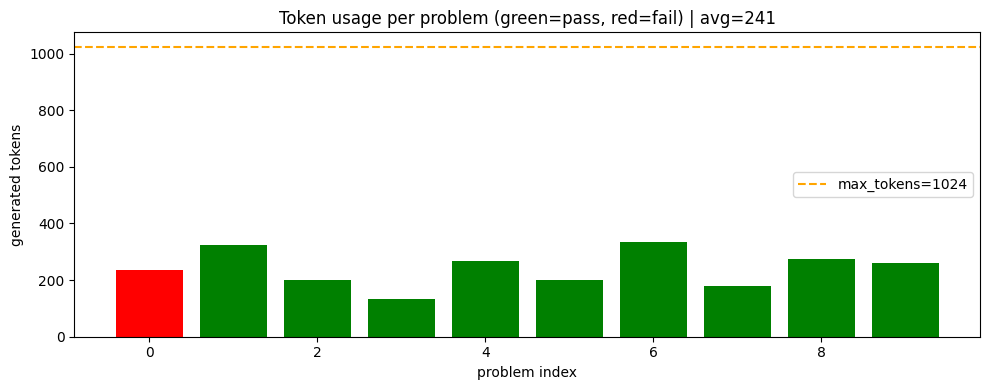

In [13]:
import matplotlib.pyplot as plt

token_counts = [len(o.outputs[0].token_ids) for o in outputs]
pass_status = [r["passed"] for r in inspection_results]

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["green" if p else "red" for p in pass_status]
ax.bar(range(len(token_counts)), token_counts, color=colors)
ax.set_xlabel("problem index")
ax.set_ylabel("generated tokens")
ax.set_title(f"Token usage per problem (green=pass, red=fail) | avg={sum(token_counts)/len(token_counts):.0f}")
ax.axhline(y=MAX_TOKENS, color="orange", linestyle="--", label=f"max_tokens={MAX_TOKENS}")
ax.legend()
plt.tight_layout()
plt.show()

# flag problems that hit max_tokens (likely truncated mid-generation)
truncated = [i for i, t in enumerate(token_counts) if t >= MAX_TOKENS - 5]
if truncated:
    print(f"\n⚠ {len(truncated)} completions may be truncated (hit max_tokens):")
    for i in truncated:
        print(f"  problem {i}: {inspection_results[i]['task_id']}")

In [14]:
out_path = "evaluation/awq_inspection_log.jsonl"
os.makedirs(os.path.dirname(out_path), exist_ok=True)

with open(out_path, "w") as f:
    for ex, out, res in zip(ds, outputs, inspection_results):
        record = {
            **res,
            "problem":           ex["prompt"],
            "canonical":         ex["canonical_solution"],
            "model_completion":  out.outputs[0].text,
            "model_code":        extract_code(out.outputs[0].text),
            "model_reasoning":   extract_reasoning(out.outputs[0].text),
            "test_harness":      ex["test"],
        }
        f.write(json.dumps(record) + "\n")

print(f"saved full inspection log → {out_path}")
print(f"file size: {os.path.getsize(out_path)/1024:.1f} KB")

saved full inspection log → evaluation/awq_inspection_log.jsonl
file size: 32.5 KB
